# Practical Project: Exploratory Data Analysis of Oceanographic Data

In this project, we will put into practice the knowledge acquired about Pandas for data cleaning, transformation, combination, and visualization. We will work with a set of climate and oceanographic data to analyze temperature and salinity trends in different coastal regions.

To work on a real case study, we propose using the public CalCOFI *dataset*, which you can download from [this Kaggle link](https://www.kaggle.com/datasets/sohier/calcofi). You can find all the information about the dataset on the [CalCOFI (California Cooperative Oceanic Fisheries Investigations)](https://calcofi.org/data/oceanographic-data/bottle-database/) website, including a description of each table column.

To successfully complete these exercises, do not hesitate to consult the theoretical resources provided in class, search Google for specific function documentation to understand available parameters, or even use an LLM (such as Gemini or ChatGPT) to better understand the requirements or solve more complex segments.

**Note on LLMs:**

While AI is incredibly useful for manipulating DataFrames and refining plots (especially for aesthetics), it is crucial to review and understand the generated code. AI frequently makes assumptions that may not be correct for a specific use case. You must verify the data types stored in your variables (e.g., whether it is a single value, a Series, or a DataFrame), ensure that the logic follows the correct order, and analyze whether the resulting visualizations are consistent with your expectations. Ultimately, it is your understanding of Python, Pandas, and NumPy that will allow you to use AI effectively, avoiding errors and accelerating your data analysis and visualization workflow.

## 1. Data Import and Loading
The first thing we need to do is import the necessary libraries and load our datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

Before starting the time series analysis, we need to prepare our dataset. We will work with two historical files from the CalCOFI project: one with station data (`cast.csv`) and another with water samples (`bottle.csv`).

Since these are very large files, we will load them by selecting only the columns of interest to save memory.

**Data Loading**
1. Load the file `cast.csv` into the variable `df_cast`, indicating that you only want the columns `['Cst_Cnt', 'Date', 'Lat_Dec', 'Lon_Dec']`. You can do this by passing the list of columns to the `usecols` parameter. Use the parameter `low_memory=False`.
2. Load the file `bottle.csv` into the variable `df_bottle`, indicating that you only want the columns `['Cst_Cnt', 'Depthm', 'T_degC', 'Salnty']`. Also use `low_memory=False`.

In [ ]:
# Your code goes here

**Combining Dataframes**

Now we have the dates and positions in `df_cast` and the physical measurements in `df_bottle`. We need to join everything into a single table.
Use the appropriate Pandas function to combine (`merge`) both DataFrames based on the common key column: `Cst_Cnt`. Save the result in a variable named `df_final`.

In [ ]:
# Your code goes here

**Filtering Surface Data**

The combined table contains measurements at many different depths. To simplify our time series analysis, we will stick to surface water only.
Filter `df_final` to keep only those rows where the depth (`Depthm`) is less than or equal to 10 meters. Save it to `df_surface` applying `.copy()` at the end to avoid Pandas warnings later on.

In [ ]:
# Your code goes here

**Renaming Columns**

The original dataset names are somewhat cryptic. Use the `.rename()` method passing a dictionary to change the column names of your `df_surface` as follows:
* `Lat_Dec` $\rightarrow$ `Latitude`
* `Lon_Dec` $\rightarrow$ `Longitude`
* `T_degC` $\rightarrow$ `Water_Temp`
* `Salnty` $\rightarrow$ `Salinity`
* `Depthm` $\rightarrow$ `Depth`

In [ ]:
# Your code goes here

**Visualize the Table**

Display the table to check the final result.

In [ ]:
# Your code goes here

,Cst_Cnt,Depth,Water_Temp,Salinity,Date,Latitude,Longitude
0,1,0,10.500,33.4400,03/01/1949,38.833333,-124.083333
1,1,8,10.460,33.4400,03/01/1949,38.833333,-124.083333
2,1,10,10.460,33.4370,03/01/1949,38.833333,-124.083333
29,2,0,10.100,32.9500,03/01/1949,38.583333,-125.800000
30,2,10,9.890,32.9400,03/01/1949,38.583333,-125.800000
...,...,...,...,...,...,...,...
864829,34403,10,19.559,33.2876,11/09/2016,29.846780,-123.586670
864858,34404,0,18.744,33.4083,11/06/2016,32.953770,-117.279770
864859,34404,2,18.744,33.4083,11/06/2016,32.953770,-117.279770
864860,34404,5,18.692,33.4150,11/06/2016,32.953770,-117.279770


## 2. Time Series and Indexes
Time series are samples of values taken over time. Pandas allows us to manage them easily, but first we must transform the date column into the correct format.

**Column Types**

Check the type of each column using the `dtypes` attribute.

In [ ]:
# Your code goes here

Cst_Cnt         int64
Depth           int64
Water_Temp    float64
Salinity      float64
Date              str
Latitude      float64
Longitude     float64
dtype: object

**Type Conversion**

As you can see, the date column is of type `str` (text). We want it to be of type `Datetime` so that we can easily operate with dates. Therefore, perform the type conversion for this column. You can use the `to_datetime` method.

To verify if you did it correctly, you can print the column types again.

In [ ]:
# Your code goes here

**Convert Date into the Index**

Set the `Date` column as the dataframe index using `set_index`, and sort the index chronologically (`sort_index`). Display the first rows of the table to see the result.

In [ ]:
# Your code goes here

,Cst_Cnt,Depth,Water_Temp,Salinity,Latitude,Longitude
Date,,,,,,
1949-02-28,28,0,14.370,33.5500,32.666666,-118.166666
1949-02-28,28,10,14.220,33.5500,32.666666,-118.166666
1949-02-28,28,9,14.230,33.5500,32.666666,-118.166666
1949-03-01,29,0,13.600,33.4200,32.350000,-118.883333
1949-03-01,29,9,13.650,33.4900,32.350000,-118.883333
...,...,...,...,...,...,...
2016-11-21,34331,0,14.793,33.2758,35.021400,-120.918880
2016-11-21,34330,10,13.740,33.3588,35.087820,-120.777080
2016-11-21,34330,10,13.740,33.3598,35.087820,-120.777080


**Extra**

When we convert the Date column into the index, we are transforming our DataFrame into a Time Series. This gives Pandas the ability to treat time intelligently. Look at some examples:

In [10]:
# Show data from the year 1999
display(df_surface.loc['1999'])

# Show data from May to August 1999
display(df_surface.loc['1999-05':'1999-08'])

,Cst_Cnt,Depth,Water_Temp,Salinity,Latitude,Longitude
Date,,,,,,
1999-01-09,29077,1,14.74,33.468,32.913333,-117.395000
1999-01-09,29077,10,14.51,33.469,32.913333,-117.395000
1999-01-09,29077,0,14.75,33.460,32.913333,-117.395000
1999-01-09,29077,1,14.75,33.469,32.913333,-117.395000
1999-01-09,29076,1,14.19,33.486,32.956666,-117.305000
...,...,...,...,...,...,...
1999-10-19,29336,0,15.53,33.640,34.893333,-121.198333
1999-10-19,29335,10,16.14,33.593,34.721666,-121.550000
1999-10-19,29335,1,16.13,33.592,34.721666,-121.550000


,Cst_Cnt,Depth,Water_Temp,Salinity,Latitude,Longitude
Date,,,,,,
1999-08-07,29208,10,18.87,33.601,32.885,-117.406666
1999-08-07,29208,9,19.00,33.602,32.885,-117.406666
1999-08-07,29208,1,20.12,33.616,32.885,-117.406666
1999-08-07,29208,1,20.12,33.616,32.885,-117.406666
1999-08-07,29208,0,20.12,33.610,32.885,-117.406666
...,...,...,...,...,...,...
1999-08-23,29269,0,15.38,33.660,34.720,-121.550000
1999-08-23,29268,10,16.51,33.651,34.395,-122.245000
1999-08-23,29268,2,16.51,33.651,34.395,-122.245000


## 3. Handling NaN Values

In the collection of oceanographic data from buoys or sensors, it is very common for reading errors to occur, resulting in NaN values. Do the following:

1. Count how many NaN values are in each column of `df_surface`. The `isna` method will be useful, although you will need to sum them afterwards.
2. For the `Salinity` column, fill the missing values with the mean of the same column. The `fillna` method might be useful.
3. For the `Water_Temp` column, use the `.interpolate(method="linear")` method to estimate values based on adjacent readings.
4. To check that the new table is NaN-free, display the total number of NaN values in the table.

In [ ]:
# Your code goes here

Null values per column:
Cst_Cnt          0
Depth            0
Water_Temp    2130
Salinity      3774
Latitude         0
Longitude        0
dtype: int64

NaNs after treatment: 0


**Note on Interpolation:**

Notice that we sorted the dataset by date before applying `.interpolate()`. This is necessary because the linear method draws a line between the previous and next value in the DataFrame's current order. If we didn't sort, we could be mixing summer temperatures with winter ones, and the result would be wrong.

**Extra:**

Pandas allows using `interpolate(method='time')`. This method is even more precise because it doesn't just look at which row comes before, but looks at the actual distance in time (for example, if there is a gap of two days or ten, the slope of the line changes). To do this, however, the index must be of type `DatetimeIndex`.

## 4. Time Aggregation

We might be interested in reducing the amount of data by reducing its "resolution." For example, instead of having several samples for each day, having only one, or even just one per month. We can do this with the `resample` method.

**By Months**

Try calculating the average temperature and salinity for each month using this method. You can do this using the `"ME"` (Month End) parameter when calling `resample()`.

In [ ]:
# Your code goes here

,Water_Temp,Salinity
Date,,
1949-02-28,14.273333,33.550000
1949-03-31,13.825648,33.412366
1949-04-30,13.064447,33.299966
1949-05-31,14.504581,33.289087
1949-06-30,16.117910,33.435315
...,...,...
2016-07-31,18.004935,33.415184
2016-08-31,NaN,NaN
2016-09-30,NaN,NaN


Also try displaying the annual average temperature and salinity using `"YE"` instead of `"ME"`.

In [ ]:
# Your code goes here

,Water_Temp,Salinity
Date,,
1949-12-31,16.074540,33.275380
1950-12-31,15.794141,33.350493
1951-12-31,16.517266,33.486409
1952-12-31,15.933937,33.450228
1953-12-31,15.388466,33.510353
...,...,...
2012-12-31,15.524391,33.430818
2013-12-31,14.969689,33.485540
2014-12-31,17.183455,33.445570


However, if we want to show the average by months, across all years, we cannot use `resample`, as we are changing the period the series covers. Instead, we must use `groupby` on the month of the date.

In [ ]:
# Your code goes here

,Water_Temp,Salinity
Date,,
1,15.058572,33.454538
2,15.060874,33.524429
3,14.870233,33.512789
4,14.849855,33.478920
5,14.578922,33.408346
6,16.060681,33.554735
7,17.289236,33.463943
8,18.271162,33.506083
9,18.776601,33.494588


## 5. Result Visualization

Now, we will visualize the data to draw conclusions.

### Line Chart

**Evolution of salinity by months**

Draw a line chart showing the monthly evolution of water salinity over the years. Use the `df_seasonal` DataFrame for this. You can use the `plot` method of the Dataframe class.

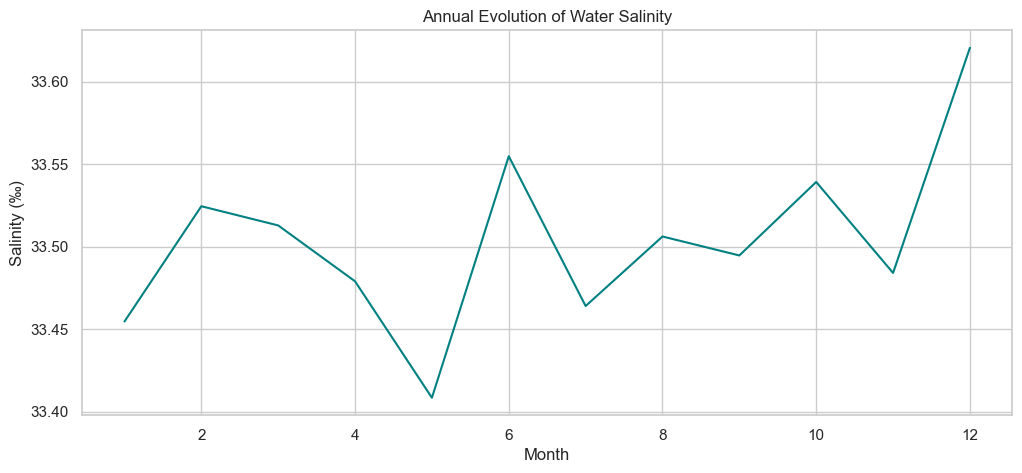

In [ ]:
# Your code goes here

**Evolution of annual salinity**

Draw a chart showing the annual evolution of water salinity. To do this, use the `df_yearly` DataFrame.

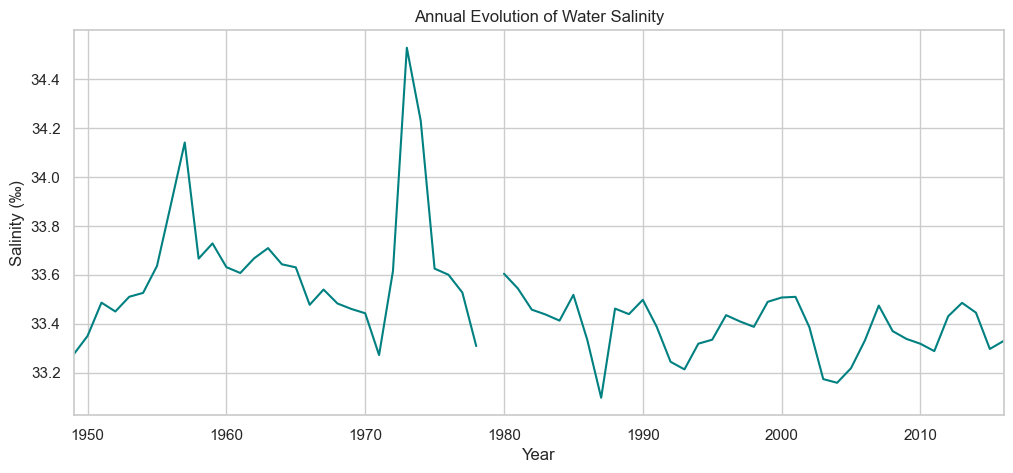

In [ ]:
# Your code goes here

**Month-by-month salinity evolution**

Next, show the salinity evolution again, but this time use the `df_monthly` Dataframe.

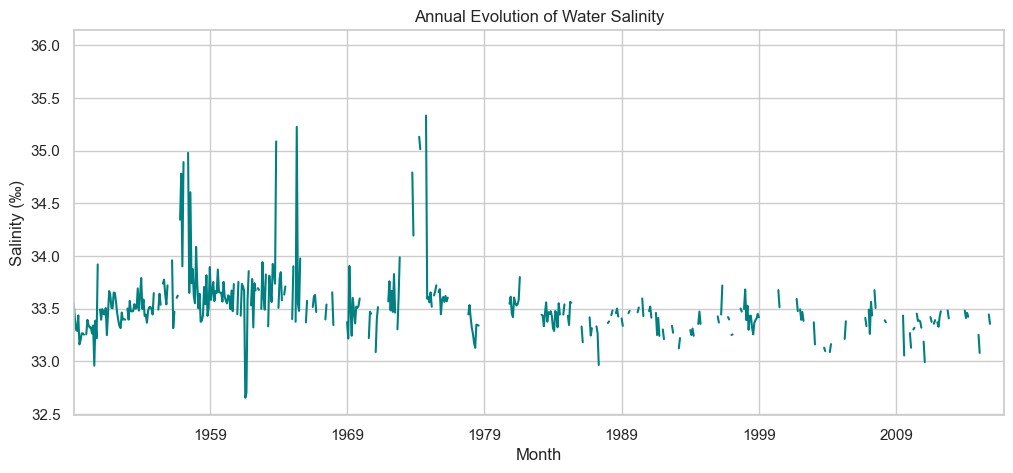

In [ ]:
# Your code goes here

**Comments on the graph**

Notice that the graph shows years without data. This is because there are months (or even years) for which we have no information. If you inspect the `df_monthly` `Dataframe`, you will see there are NaNs in some months. Therefore, be careful when inspecting the annual graph without ensuring that the data we have for each year is sufficient, otherwise it can lead us to wrong conclusions. Since salinity is seasonal, if for example we only have data for months where it is highest, the average salinity for that year will come out disproportionately high.

### Boxplot
**Monthly temperature boxplot**

Create a boxplot showing the temperature distribution grouped by months. To do this, we will need to know, for each row in the `df_surface` table, which month it is. Therefore, add a `Month` column to it. Then, use it to draw the graph using the `sns.boxplot` function.

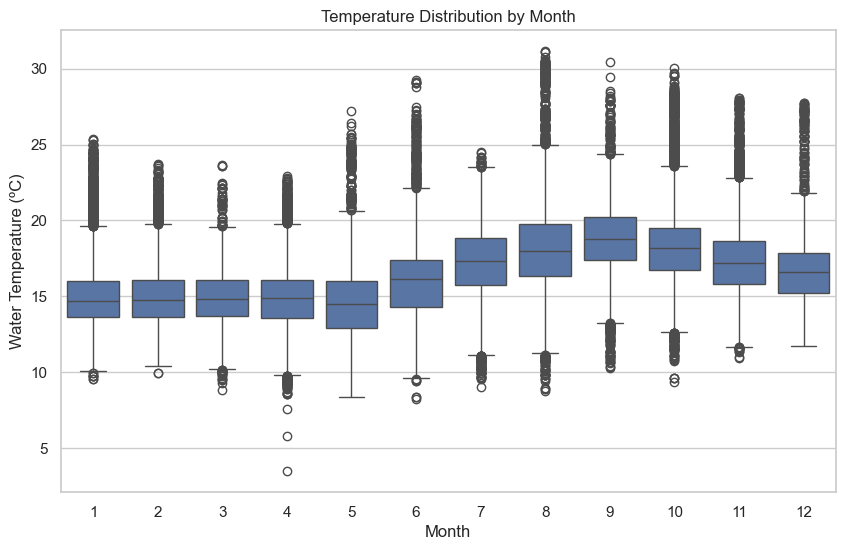

In [ ]:
# Your code goes here

### Temperature Map

Next, we are going to take advantage of having the coordinates (latitude and longitude) of each row to draw a map of the temperatures of the samples we have. To do this, however, we must follow several steps:

1. **Creation of *bins*.** What we want is to group by coordinates. The problem is that these variables have continuous values, so we must discretize them (or group them into *bins*). We can do this easily by rounding. Create two new columns for `df_surface`, named `'Lat_Round'` and `'Lon_Round'`, which are the result of rounding the latitude and longitude, respectively.

In [ ]:
# Your code goes here

2. **Grouping by coordinates.** Now, create a `Dataframe` that is the grouping by rounded coordinates of `df_surface`, and calculate the average temperature at those coordinates.

In [ ]:
# Your code goes here

3. **Draw the chart.** Finally, draw the chart for the new `Dataframe`. To do this, we are interested in the `plt.scatter` function, and since we are dealing with temperature data, it is most appropriate to use the `cmap='coolwarm'` color map.

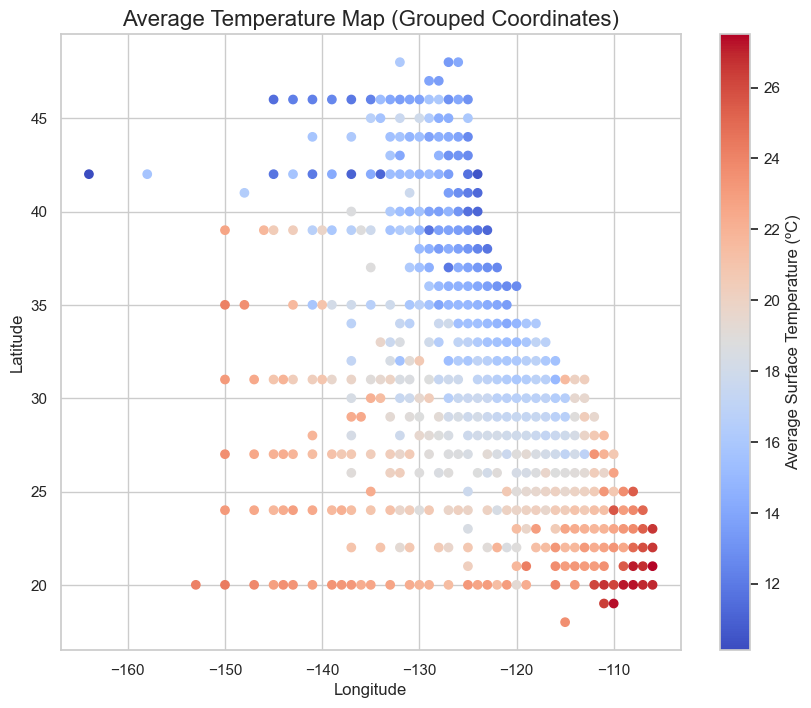

In [ ]:
# Your code goes here

**Note:**

Try changing the rounding order (to one decimal place, two, one ten...), and you will see the graph with more or less detail.

## 6. High-Performance Mathematics with NumPy

Pandas is incredibly powerful for data manipulation, but under the hood, it is built on top of **NumPy** (Numerical Python). NumPy is the core library for scientific computing in Python. It allows us to perform mathematical operations on entire columns of data instantly (a process called **vectorization**) without using slow `for` loops.

Let's see how we can combine Pandas DataFrames with NumPy's mathematical functions to enrich our oceanographic dataset.

### Calculating Anomalies and Categorization

In climatology, an *anomaly* is the difference between a specific measurement and the historical average. However, water temperature is seasonal: it is naturally colder in winter and warmer in summer. Comparing a winter measurement to a global annual average doesn't make sense.

Instead, we need to calculate the historical average **for each specific day of the year** (e.g., the average of all January 1sts) and compare our measurements against that daily baseline.

To do this efficiently, we will use `.groupby(df_surface.index.dayofyear)` combined with `.transform('mean')`. The `transform` method calculates the mean for each day of the year, but instead of collapsing the dataframe, it assigns that mean back to every original row.

We will classify the temperatures as follows:
* **Warm**: If the temperature is strictly 2ºC greater than its historical daily mean.
* **Cold**: If the temperature is strictly 2ºC less than its historical daily mean.
* **Normal**: If it falls within the $\pm 2$ºC range.

Now:

1. Create a variable `threshold` to define the percentage (2ºC in this case, but you can adjust it at will).
2. Group `df_surface` by the day of the year (`df_surface.index.dayofyear`) and calculate the mean of `Water_Temp` using `.transform('mean')`. Store it in a new column called `Historical_Daily_Mean`.
3. Create a new column called `Temp_Anomaly` by subtracting the `Historical_Daily_Mean` from the `Water_Temp` column.
4. Calculate the percentage thresholds: create the variables `upper_bound` (`Historical_Daily_Mean` +2ºC) and `lower_bound` (`Historical_Daily_Mean` -2ºC). 
5. Use nested `np.where()` functions to create a new column called `Water_Category` assigning the labels `'Warm'`, `'Cold'`, or `'Normal'`.
6. Display the first 10 rows showing the original temperature, the daily mean, the anomaly, and the category.


In [ ]:
# Your code goes here

,Water_Temp,Historical_Daily_Mean,Temp_Anomaly,Water_Category
Date,,,,
1949-02-28,14.37,14.951536,-0.581536,Normal
1949-02-28,14.22,14.951536,-0.731536,Normal
1949-02-28,14.23,14.951536,-0.721536,Normal
1949-03-01,13.60,14.432791,-0.832791,Normal
1949-03-01,13.65,14.432791,-0.782791,Normal
1949-03-01,13.64,14.432791,-0.792791,Normal
1949-03-01,13.20,14.432791,-1.232791,Normal
1949-03-01,13.26,14.432791,-1.172791,Normal
1949-03-01,13.26,14.432791,-1.172791,Normal


Water_Category
Normal    60961
Cold      16271
Warm      14198
Name: count, dtype: int64

#### Visualizing Seasonal Anomalies

*Note: This is an advanced visualization to demonstrate the power of what we just calculated. You can just run the cell and observe the results!*

To truly understand our seasonal anomalies, we can plot a specific year (e.g., 1998, a known *El Niño* year) and visualize the actual temperatures against our calculated historical baseline.

We will use `matplotlib` to:
1. Draw a dashed line representing the **Historical Daily Mean**.
2. Shade the **"Normal" area** (between -2ºC and +2ºC of the mean) using `plt.fill_between()`.
3. Plot the **actual water temperatures** as points, colored by the category we just assigned them (Red for Warm, Blue for Cold, Green for Normal).

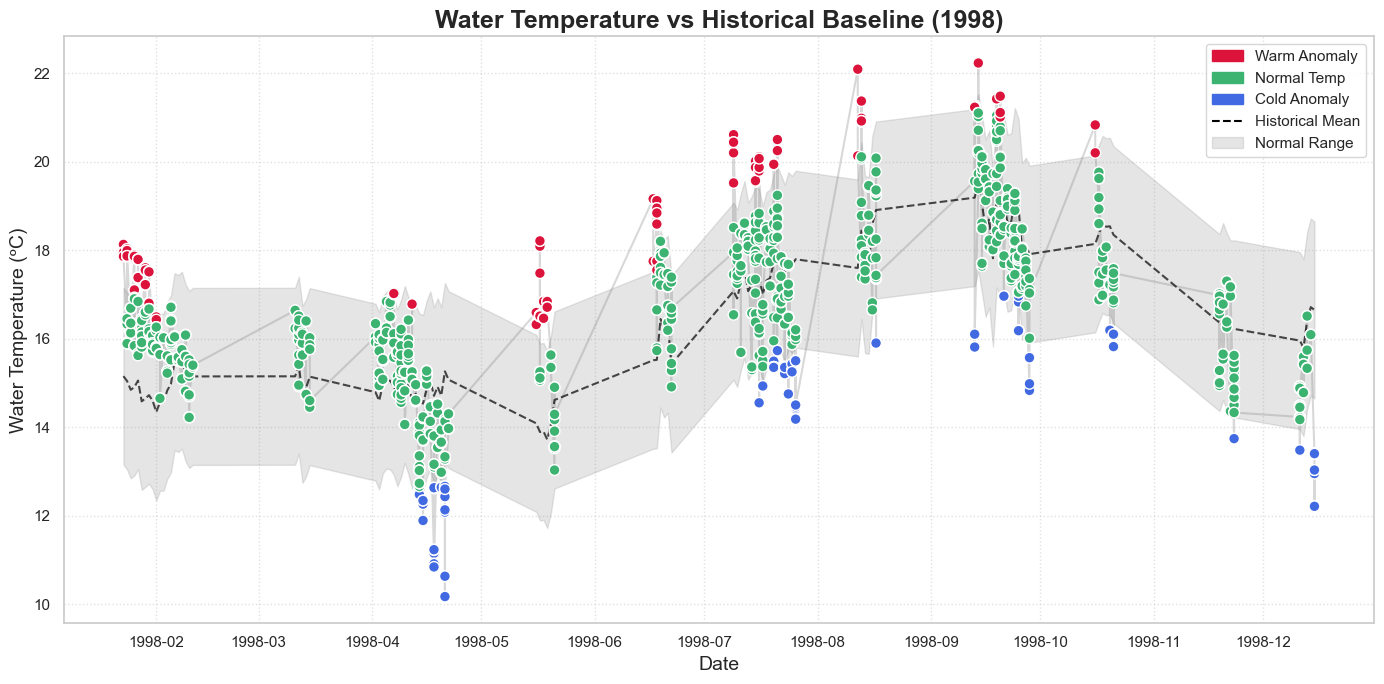

In [53]:
import matplotlib.patches as mpatches

# 1. Filter data for a specific year and sort it chronologically
year_to_plot = '1998'
df_plot = df_surface.loc[year_to_plot].sort_index()

# 2. Set up the figure
plt.figure(figsize=(14, 7))

# 3. Shade the "Normal" area (90% to 110% of the historical mean)
plt.fill_between(df_plot.index, 
                 df_plot['Historical_Daily_Mean'] - threshold, 
                 df_plot['Historical_Daily_Mean'] + threshold, 
                 color='gray', alpha=0.2, label='Normal Range (±10%)')

# 4. Draw the Historical Daily Mean line
plt.plot(df_plot.index, df_plot['Historical_Daily_Mean'], 
         color='black', linestyle='--', alpha=0.7, label='Historical Daily Mean')

# 5. Plot the actual temperature readings
# Map our categories to specific colors
color_map = {'Warm': 'crimson', 'Cold': 'royalblue', 'Normal': 'mediumseagreen'}
point_colors = df_plot['Water_Category'].map(color_map)

# Draw a faint line connecting the readings to show the timeline
plt.plot(df_plot.index, df_plot['Water_Temp'], color='gray', alpha=0.3, zorder=1)

# Draw the points on top, colored by category
plt.scatter(df_plot.index, df_plot['Water_Temp'], 
            c=point_colors, s=60, edgecolor='white', zorder=5)

# 6. Customize the chart details
plt.title(f'Water Temperature vs Historical Baseline ({year_to_plot})', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Water Temperature (ºC)', fontsize=14)

# Create a custom legend so the colors make sense
warm_patch = mpatches.Patch(color='crimson', label='Warm Anomaly')
cold_patch = mpatches.Patch(color='royalblue', label='Cold Anomaly')
normal_patch = mpatches.Patch(color='mediumseagreen', label='Normal Temp')
mean_line = plt.Line2D([0], [0], color='black', linestyle='--', label='Historical Mean')
range_patch = mpatches.Patch(color='gray', alpha=0.2, label='Normal Range')

plt.legend(handles=[warm_patch, normal_patch, cold_patch, mean_line, range_patch], 
           loc='upper right', fontsize=11)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Show the beautiful chart!
plt.show()

### Vectorized Mathematical Operations

NumPy provides highly optimized mathematical functions. Suppose we want to calculate the approximate distance of each oceanographic sample from the coast of San Diego, California (Latitude: 32.7, Longitude: -117.2).

For the purpose of this exercise, and to keep it simple, we will use the Euclidean distance formula:
$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

Note that this is a very rough approximation and does not account for the curvature of the Earth, but it serves well for our learning purposes.

We will use `np.square()` to square the differences and `np.sqrt()` to calculate the square root.

1. Define the reference coordinates: `sd_lat = 32.7` and `sd_lon = -117.2`.
2. Use `np.square()` to calculate the squared difference between the `Latitude` column and `sd_lat`.
3. Use `np.square()` to calculate the squared difference between the `Longitude` column and `sd_lon`.
4. Add both squared differences, and pass the result to `np.sqrt()` to get the final distance. Store it in a new column called `Dist_to_SD`.
5. Sort the DataFrame by this new distance in ascending order (using `.sort_values()`) to find the samples taken closest to San Diego, and display the first 5 rows.


In [ ]:
# Your code goes here

,Latitude,Longitude,Water_Temp,Dist_to_SD
Date,,,,
2003-04-03,32.631666,-117.215000,14.08,0.069961
2003-04-03,32.631666,-117.215000,13.81,0.069961
2003-04-03,32.631666,-117.215000,12.48,0.069961
2003-04-03,32.631666,-117.215000,14.08,0.069961
2003-04-03,32.631666,-117.178333,14.50,0.071687


## 7. Extra: Introduction to SQL with Pandasql
Pandas is a wonderful tool, but in the world of Data Analysis and Data Engineering, there is a king language that dominates almost all corporate databases: **SQL (Structured Query Language)**.

**What is SQL and why is it useful?**
SQL is a "declarative" language. This means that, unlike Python where you write step-by-step *how* to do things, in SQL you simply describe *what* you want to get, and the engine takes care of finding the best way to give it to you.

Thanks to the `pandasql` library, we can write SQL queries and execute them directly on our Pandas DataFrames.

### Install and Import the Library
First, we need to install and import the library, and create a small helper function so that SQL can read the variables from our Notebook.

In [22]:
# Install the library (remove '#' if not installed)
# !pip install pandasql

from pandasql import sqldf

# Create a short function to avoid writing globals() all the time
pysqldf = lambda q: sqldf(q, globals())

### Basic Syntax (SELECT, FROM, LIMIT)

The most basic structure of an SQL query consists of three keywords:
* **SELECT:** Which columns do I want to see? (If you put an asterisk `*`, you want them all).
* **FROM:** From which DataFrame(s) do I want to extract the data?
* **LIMIT:** (Optional) How many rows do I want to see at most? (The equivalent of Pandas' `.head()`).

Write an SQL query (inside triple quotes `"""`) to select only the columns for the identification key (`Cst_Cnt`), depth (`Depthm`), and temperature (`T_degC`) from the samples dataframe (`df_bottle`). Limit the result to just 5 rows.

In [ ]:
# Your code goes here

,Cst_Cnt,Depthm,T_degC
0,1,0,10.50
1,1,8,10.46
2,1,10,10.46
3,1,19,10.45
4,1,20,10.45


### Filters

Where SQL really shines is in filters.
* **WHERE:** Works as a condition. It allows you to filter rows (ex: `WHERE T_degC > 20`).
* **ORDER BY:** Sorts the results by a column. You can add **DESC** at the end if you want it from highest to lowest.

We want to find the warmest waters among all the samples. Write a query on `df_bottle` that returns all columns (`*`), but only those where the water temperature (`T_degC`) is higher than 25 degrees. Sort the result by temperature in descending order (from hottest to coldest) and show the top 10.

In [ ]:
# Your code goes here

,Cst_Cnt,Depthm,T_degC,Salnty
0,9117,0,31.14,35.15
1,9138,0,31.12,35.43
2,9124,0,31.09,35.39
3,9116,0,30.76,34.97
4,9123,0,30.58,35.20
5,9145,19,30.54,35.83
6,9137,0,30.49,35.41
7,9125,10,30.48,35.33
8,9117,10,30.46,35.07
9,9183,0,30.46,35.41


### Combining Tables (JOIN)
At the beginning of the *notebook*, we used `pd.merge()` to join geographic data (`df_cast`) with temperature data (`df_bottle`). In SQL, this is done with the **JOIN** clause.

We must indicate the key that connects both tables using the word **ON**. Also, to avoid confusion if two tables have columns with the same name, we usually put a short alias on the tables (for example `c` for cast and `b` for bottle).

**Example Syntax:**

```sql
SELECT b.column1, c.column2
FROM df_bottle b
JOIN df_cast c ON b.ID = c.ID
```

Write a query that joins the two tables using the shared key `Cst_Cnt`.
We want to obtain a new DataFrame containing:
1. The Date (`Date`) from the `df_cast` dataframe.
2. The Latitude (`Lat_Dec`) from the `df_cast` dataframe.
3. The Temperature (`T_degC`) from the `df_bottle` dataframe.
Add a `WHERE` filter so that it only shows surface data (where `Depthm` from `df_bottle` is 0). Limit the result to 5.

In [ ]:
# Your code goes here

,Date,Lat_Dec,T_degC
0,03/01/1949,38.833333,10.5
1,03/01/1949,38.583333,10.1
2,03/02/1949,38.475000,10.2
3,03/02/1949,38.333333,10.4
4,03/02/1949,38.233333,10.5
